# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Placement Dataset](https://www.kaggle.com/datasets/amar5693/student-placement-prediction-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

/kaggle/input/datasets/amar5693/student-placement-prediction-dataset/Student_Placement_Career_Prediction_Dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Student_Placement_Career_Prediction_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,student_id,age,gender,branch,cgpa,internship_count,project_count,certifications_count,coding_skills_score,communication_skills_score,soft_skills_score,hackathon_participation,placement_status
0,1,23,Male,IT,8.99,4,6,2,41,71,59,Yes,Placed
1,2,24,Female,Mechanical,8.36,4,7,5,42,64,97,No,Placed
2,3,22,Female,EEE,7.18,4,5,2,84,98,51,No,Placed
3,4,24,Female,Mechanical,6.28,0,2,4,60,100,92,No,Not Placed
4,5,24,Female,IT,5.30,3,4,1,78,61,77,No,Not Placed


## last Five row

In [4]:
df.tail()

,student_id,age,gender,branch,cgpa,internship_count,project_count,certifications_count,coding_skills_score,communication_skills_score,soft_skills_score,hackathon_participation,placement_status
9995,9996,21,Female,CSE,5.27,4,6,0,74,65,63,Yes,Not Placed
9996,9997,21,Male,Mechanical,7.23,0,7,4,58,95,89,No,Placed
9997,9998,21,Female,Civil,8.70,1,4,2,82,42,76,No,Not Placed
9998,9999,21,Male,Mechanical,9.04,3,5,3,86,72,55,No,Placed
9999,10000,23,Male,CSE,9.91,2,3,4,73,78,68,No,Placed


## Shape of our dataset

In [5]:
df.shape

(10000, 13)

## List out all columns

In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'branch', 'cgpa', 'internship_count',
       'project_count', 'certifications_count', 'coding_skills_score',
       'communication_skills_score', 'soft_skills_score',
       'hackathon_participation', 'placement_status'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

student_id                      int64
age                             int64
gender                         object
branch                         object
cgpa                          float64
internship_count                int64
project_count                   int64
certifications_count            int64
coding_skills_score             int64
communication_skills_score      int64
soft_skills_score               int64
hackathon_participation        object
placement_status               object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  int64  
 1   age                         10000 non-null  int64  
 2   gender                      10000 non-null  object 
 3   branch                      10000 non-null  object 
 4   cgpa                        10000 non-null  float64
 5   internship_count            10000 non-null  int64  
 6   project_count               10000 non-null  int64  
 7   certifications_count        10000 non-null  int64  
 8   coding_skills_score         10000 non-null  int64  
 9   communication_skills_score  10000 non-null  int64  
 10  soft_skills_score           10000 non-null  int64  
 11  hackathon_participation     10000 non-null  object 
 12  placement_status            10000 non-null  object 
dtypes: float64(1), int64(8), object(

## Check Null Value

In [9]:
df.isnull().sum()

student_id                    0
age                           0
gender                        0
branch                        0
cgpa                          0
internship_count              0
project_count                 0
certifications_count          0
coding_skills_score           0
communication_skills_score    0
soft_skills_score             0
hackathon_participation       0
placement_status              0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,student_id,age,cgpa,internship_count,project_count,certifications_count,coding_skills_score,communication_skills_score,soft_skills_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,22.499900,7.520948,1.996500,4.01950,2.50910,70.026600,69.920600,70.058800
std,2886.89568,1.708711,1.447154,1.405591,2.00148,1.71657,17.485545,17.472986,17.667285
min,1.00000,20.000000,5.000000,0.000000,1.00000,0.00000,40.000000,40.000000,40.000000
25%,2500.75000,21.000000,6.280000,1.000000,2.00000,1.00000,55.000000,55.000000,55.000000
50%,5000.50000,23.000000,7.530000,2.000000,4.00000,3.00000,70.000000,70.000000,70.000000
75%,7500.25000,24.000000,8.780000,3.000000,6.00000,4.00000,85.000000,85.000000,85.000000
max,10000.00000,25.000000,10.000000,4.000000,7.00000,5.00000,100.000000,100.000000,100.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

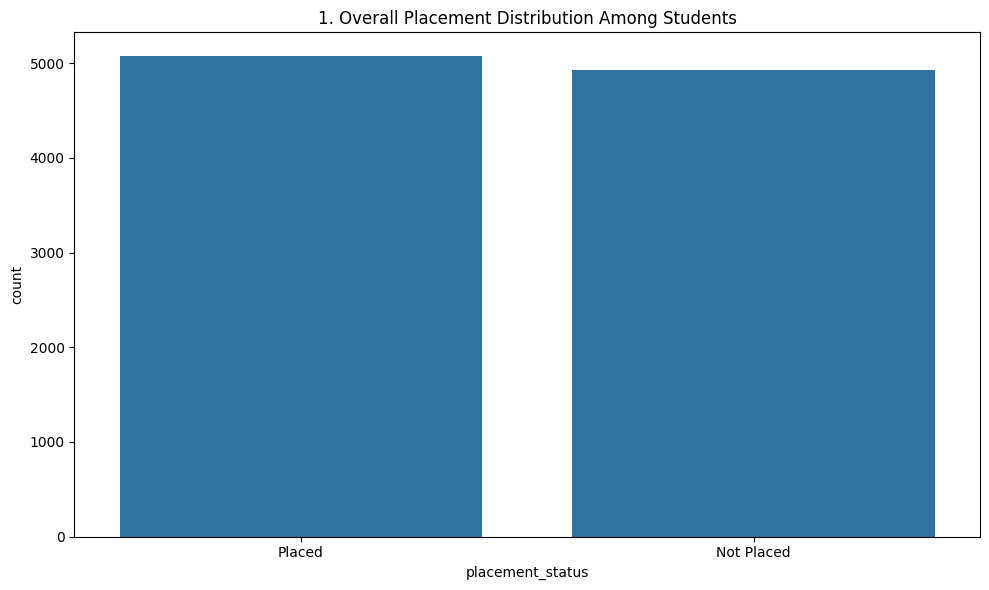

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='placement_status', data=df)
plt.title(f'{plot_no}. Overall Placement Distribution Among Students')
show_fig()
plot_no += 1

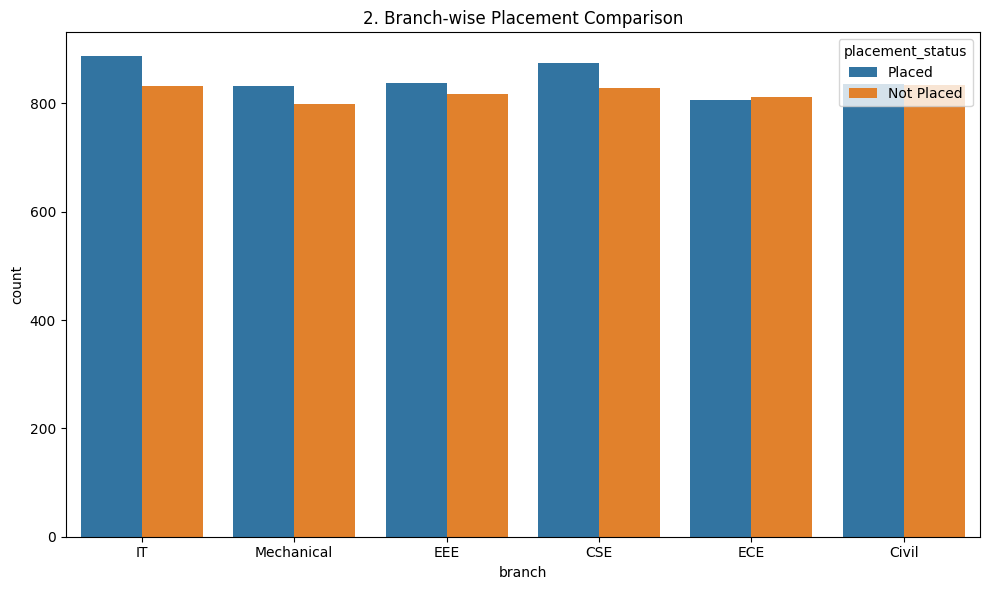

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='branch', hue='placement_status', data=df)
plt.title(f'{plot_no}. Branch-wise Placement Comparison')
show_fig()
plot_no += 1

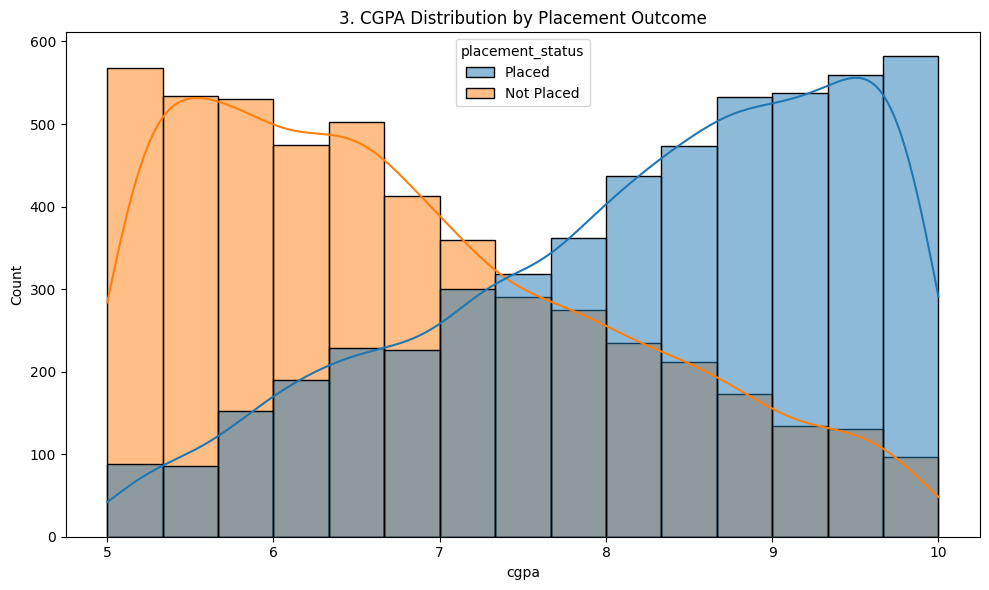

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='cgpa', hue='placement_status', kde=True, bins=15)
plt.title(f'{plot_no}. CGPA Distribution by Placement Outcome')
show_fig()
plot_no += 1

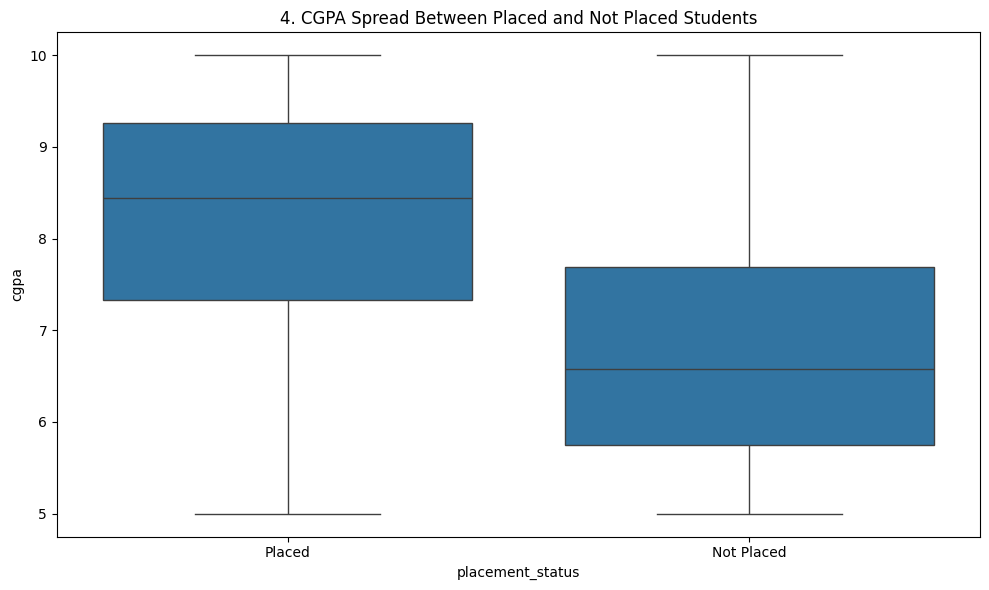

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placement_status', y='cgpa', data=df)
plt.title(f'{plot_no}. CGPA Spread Between Placed and Not Placed Students')
show_fig()
plot_no += 1

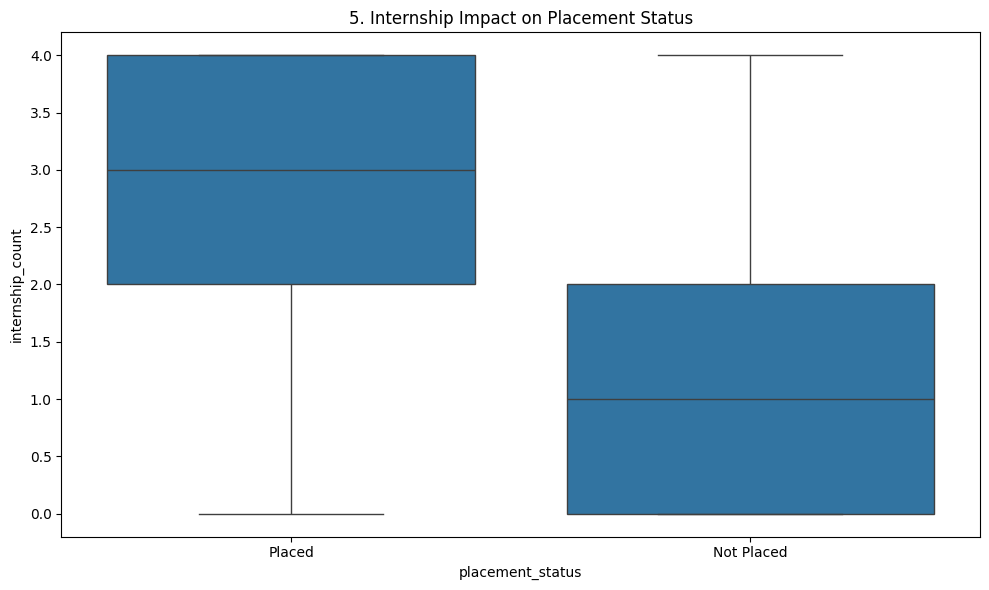

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placement_status', y='internship_count', data=df)
plt.title(f'{plot_no}. Internship Impact on Placement Status')
show_fig()
plot_no += 1

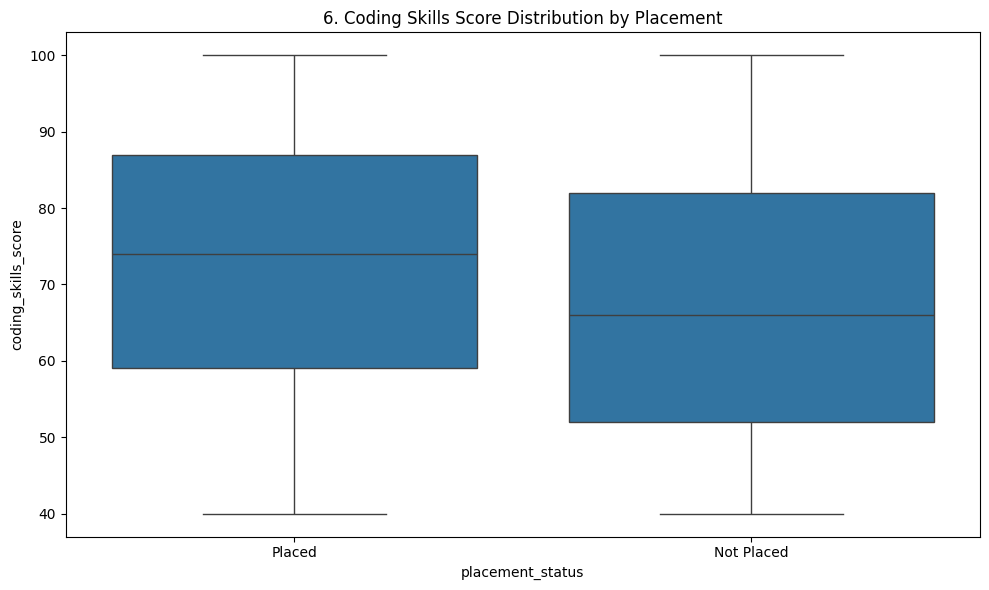

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placement_status', y='coding_skills_score', data=df)
plt.title(f'{plot_no}. Coding Skills Score Distribution by Placement')
show_fig()
plot_no += 1

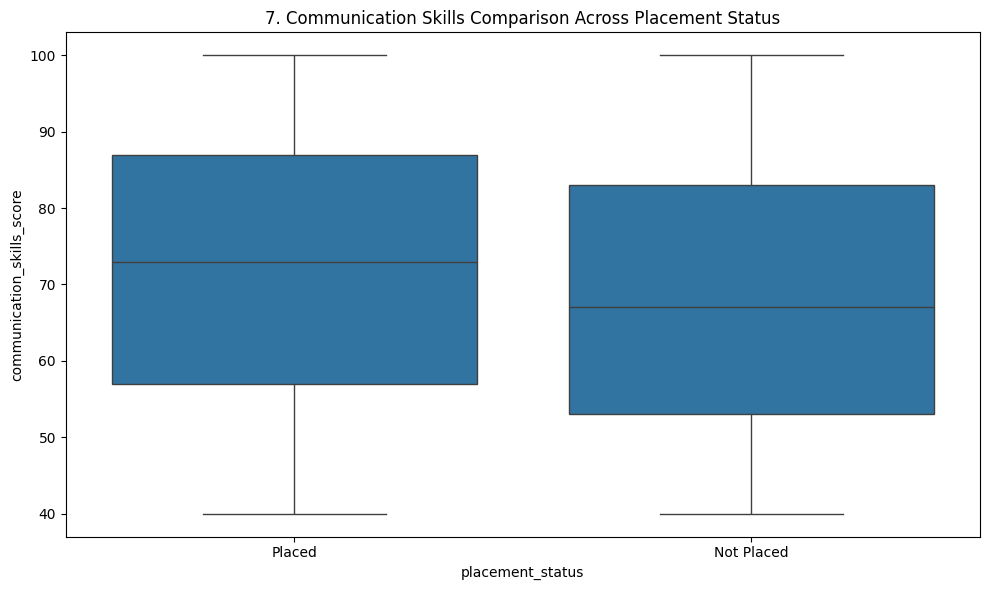

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placement_status', y='communication_skills_score', data=df)
plt.title(f'{plot_no}. Communication Skills Comparison Across Placement Status')
show_fig()
plot_no += 1

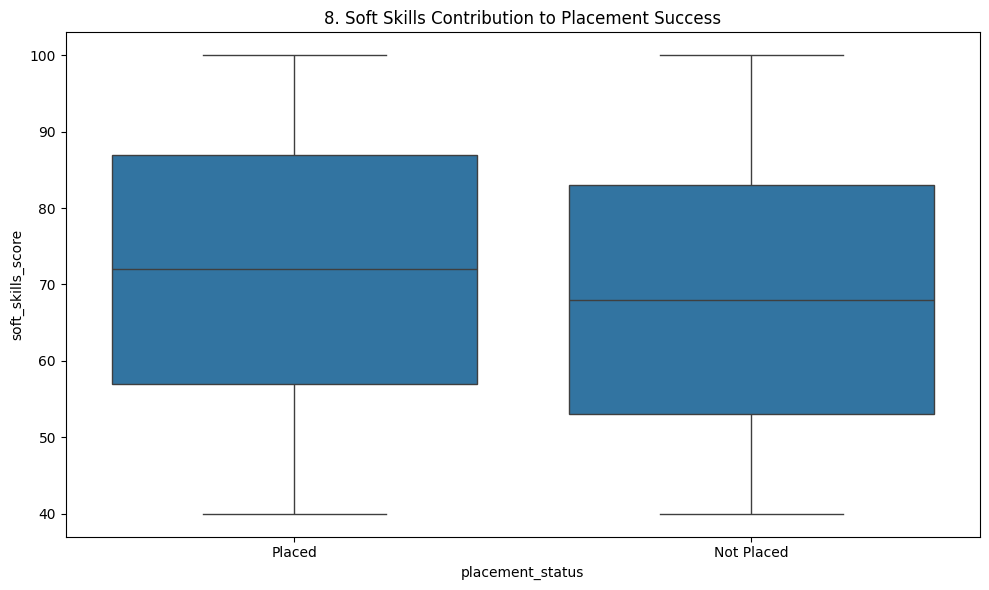

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placement_status', y='soft_skills_score', data=df)
plt.title(f'{plot_no}. Soft Skills Contribution to Placement Success')
show_fig()
plot_no += 1

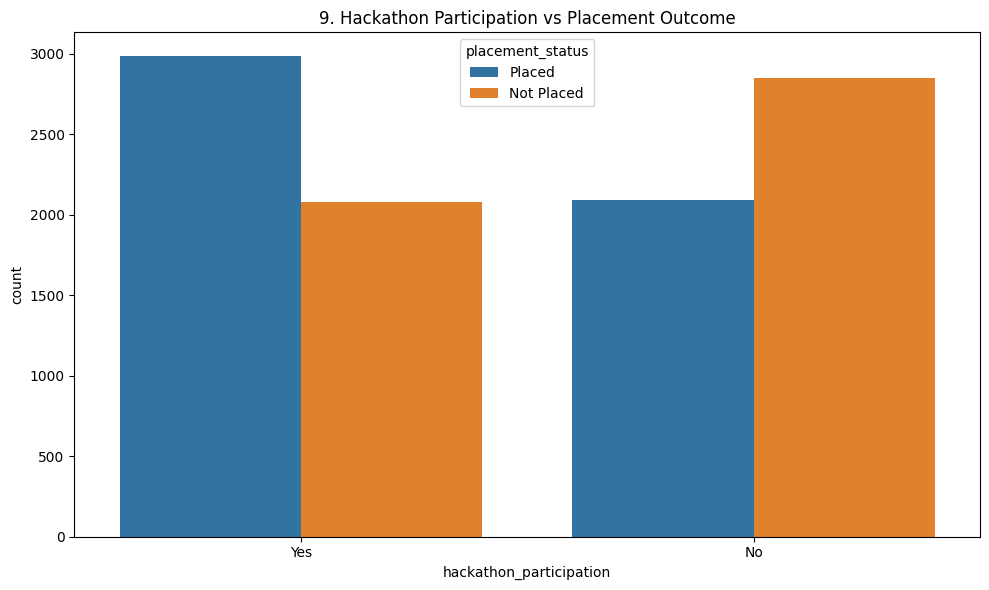

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='hackathon_participation', hue='placement_status', data=df)
plt.title(f'{plot_no}. Hackathon Participation vs Placement Outcome')
show_fig()
plot_no += 1

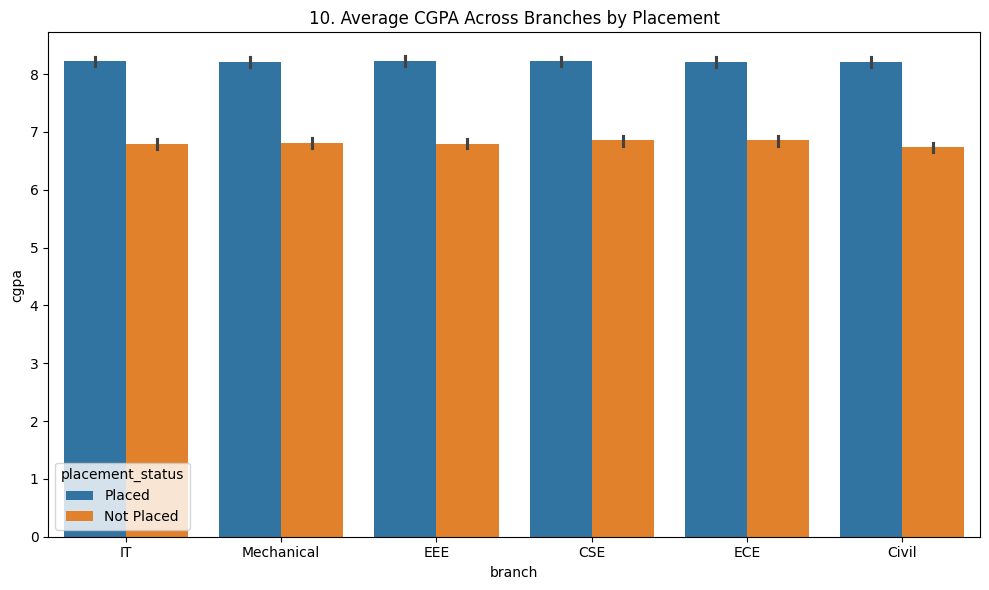

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='branch', y='cgpa', hue='placement_status', data=df)
plt.title(f'{plot_no}. Average CGPA Across Branches by Placement')
show_fig()
plot_no += 1

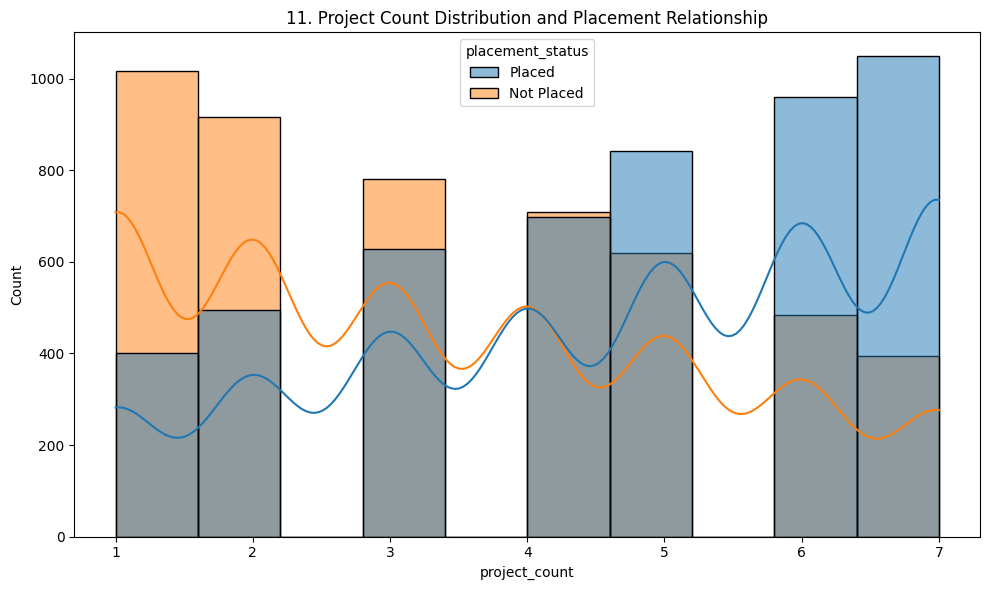

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='project_count', hue='placement_status', kde=True, bins=10)
plt.title(f'{plot_no}. Project Count Distribution and Placement Relationship')
show_fig()
plot_no += 1

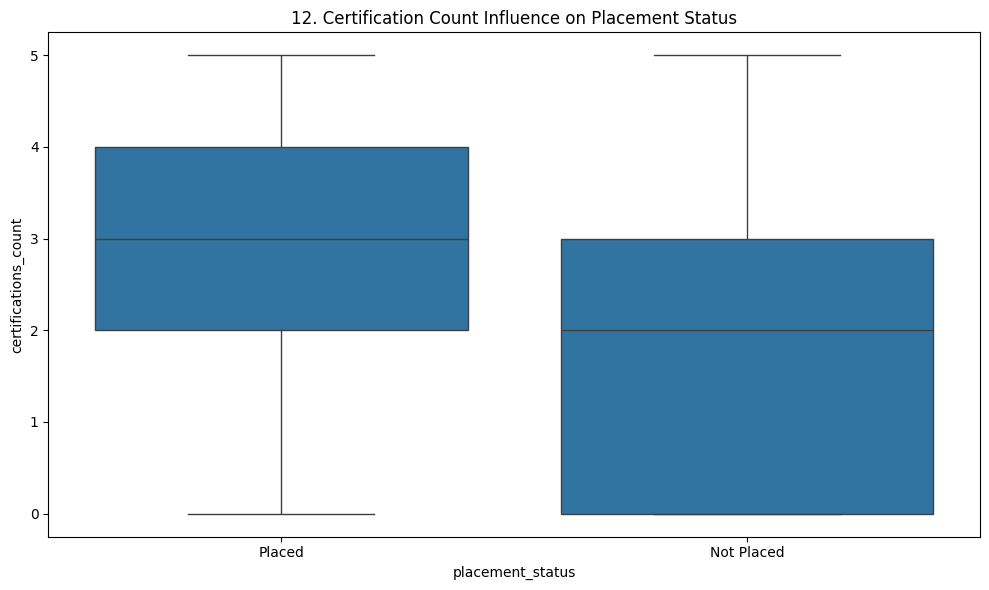

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placement_status', y='certifications_count', data=df)
plt.title(f'{plot_no}. Certification Count Influence on Placement Status')
show_fig()
plot_no += 1

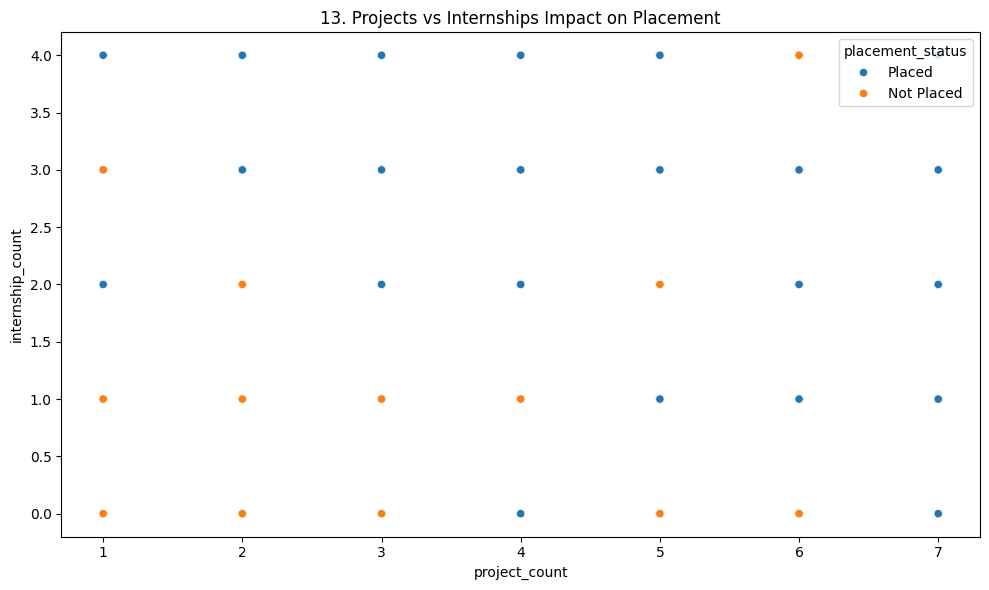

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='project_count', y='internship_count', hue='placement_status', data=df)
plt.title(f'{plot_no}. Projects vs Internships Impact on Placement')
show_fig()
plot_no += 1

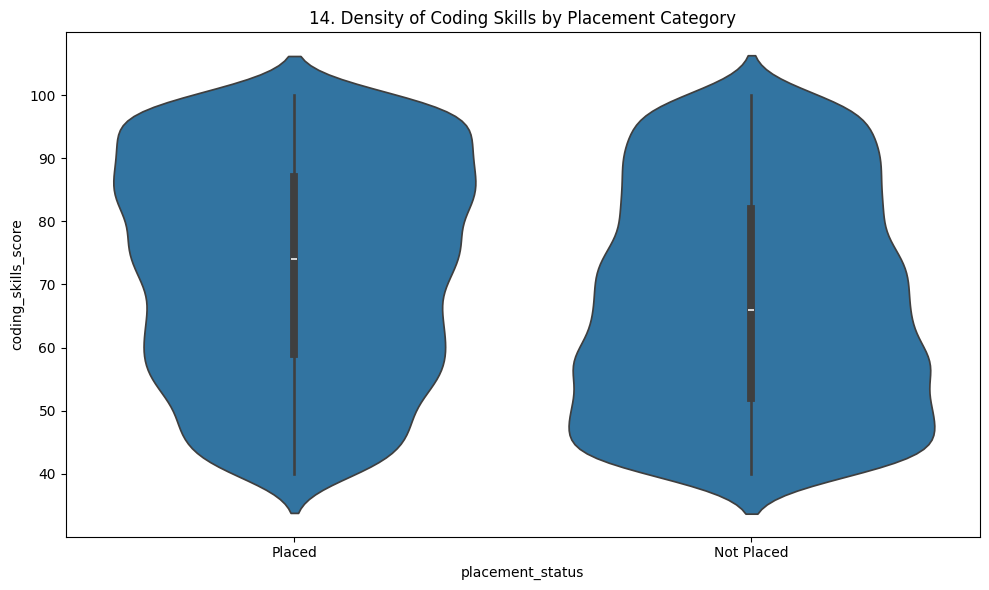

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='placement_status', y='coding_skills_score', data=df)
plt.title(f'{plot_no}. Density of Coding Skills by Placement Category')
show_fig()
plot_no += 1

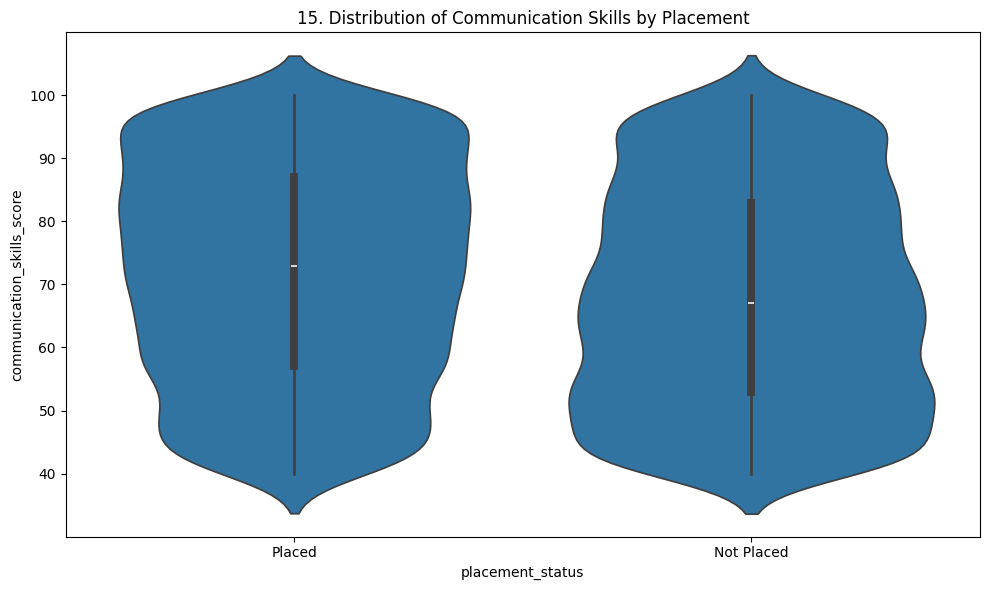

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='placement_status', y='communication_skills_score', data=df)
plt.title(f'{plot_no}. Distribution of Communication Skills by Placement')
show_fig()
plot_no += 1

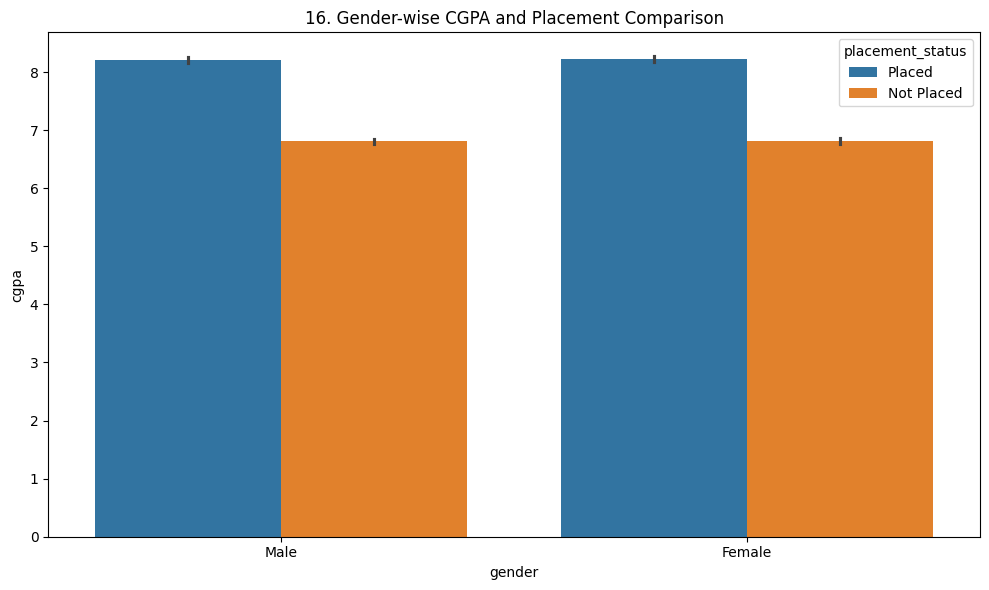

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='gender', y='cgpa', hue='placement_status', data=df)
plt.title(f'{plot_no}. Gender-wise CGPA and Placement Comparison')
show_fig()
plot_no += 1

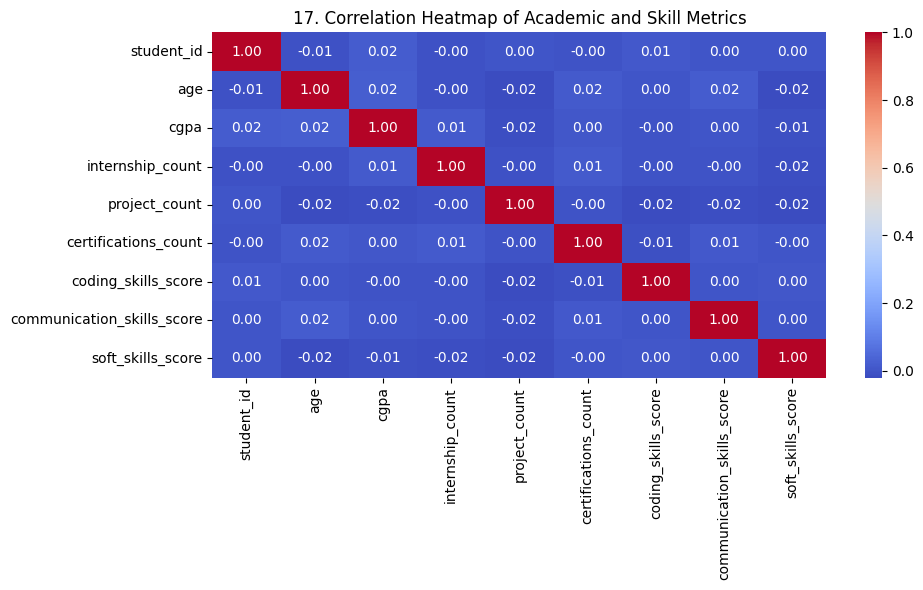

In [29]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Academic and Skill Metrics')
show_fig()
plot_no += 1

# Model Trainig

## Create a copy of dataset

In [30]:
data = df.copy()

## Encode categorical features

In [31]:
le = LabelEncoder()
for col in ['gender', 'branch', 'hackathon_participation', 'placement_status']:
    data[col] = le.fit_transform(data[col])

## Separate features and target

In [32]:
X = data.drop(['student_id', 'placement_status'], axis=1)
y = data['placement_status']

## Split into training and testing sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Apply feature scaling

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Logistic Regression model

In [35]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Make predictions

In [36]:
y_pred = model.predict(X_test)

## Print accuracy score

In [37]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.996


## Print classification report

In [38]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       985
           1       1.00      1.00      1.00      1015

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Plot confusion matrix

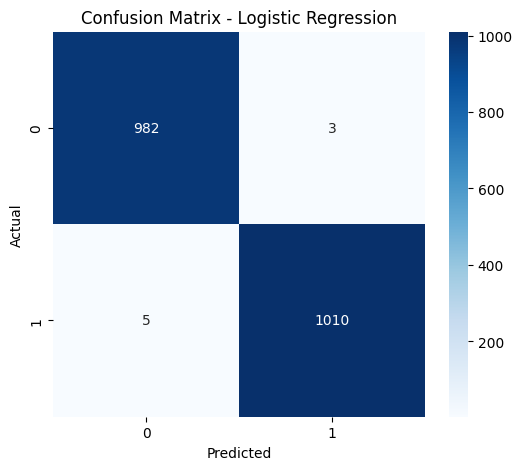

In [39]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()